# Mean stress / strain from XDMF simulation output

Reads every increment from a simulation HDF5 file and computes the
spatial-average stress and strain tensors.  Works for both elastic and
PFF simulation outputs (any file written by `IncrementalWriter`).

**Voigt convention used throughout FFTjax**

| index | 0   | 1   | 2   | 3   | 4   | 5   |
|-------|-----|-----|-----|-----|-----|-----|
| comp  | 11  | 22  | 33  | 23  | 13  | 12  |

In [55]:
import sys
sys.path.insert(0, "../src")

import xml.etree.ElementTree as ET
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

In [62]:
# ── Configuration ─────────────────────────────────────────────────────────────

H5_PATH = Path("../output/simulation/delamination/160/160_delam_preproc.h5")

# Voxels padded on each Y face by preproc_delamination.py (n_pad parameter).
# These matrix/resin layers are excluded from the spatial mean.
N_PAD_Y = 4

# Voigt component labels
VOIGT_LABELS = ["11", "22", "33", "23", "13", "12"]

In [63]:
# ── Read all increments ────────────────────────────────────────────────────────
# IncrementalWriter stores time values in the XDMF XML, not as HDF5 attrs.
# Grid shape is inferred from the first stored array (ZYX on disk).
# Y-padding voxels (N_PAD_Y on each face) are excluded from the spatial mean.

# Parse time values from the companion XDMF file
xdmf_path = H5_PATH.with_suffix(".xdmf")
time_by_key: dict[str, float] = {}
for grid in ET.parse(xdmf_path).iter("Grid"):
    name = grid.get("Name", "")
    if name.startswith("increment_"):
        t_el = grid.find("Time")
        time_by_key[name] = float(t_el.get("Value", "0")) if t_el is not None else 0.0

records = []

with h5py.File(H5_PATH, "r") as f:
    inc_keys = sorted(k for k in f.keys() if k.startswith("increment_"))
    print(f"Found {len(inc_keys)} increments")

    # Infer grid shape from the first dataset in the first increment (stored ZYX)
    first_grp = f[inc_keys[0]]
    sample_ds = next(v for v in first_grp.values() if isinstance(v, h5py.Dataset))
    n = tuple(reversed(sample_ds.shape[:3]))   # ZYX → XYZ
    print(f"Grid (XYZ)  : {n}  (inferred from '{sample_ds.name.split('/')[-1]}')")
    print(f"Y slice     : [{N_PAD_Y} : {n[1] - N_PAD_Y}]  ({n[1] - 2*N_PAD_Y} fabric voxels kept)")

    for key in inc_keys:
        grp  = f[key]
        time = time_by_key.get(key, float(key.split("_")[-1]))

        # Arrays stored ZYX on disk; Y = axis 1 in that layout.
        # Slice out the resin pad on both Y faces before averaging.
        def _mean(name):
            if name not in grp:
                return np.full(6, np.nan)
            arr = np.array(grp[name])              # (nz, ny_pad, nx[, 6])
            arr = arr[:, N_PAD_Y:-N_PAD_Y, :]      # drop Y padding on both sides
            return arr.reshape(-1, arr.shape[-1]).mean(axis=0) if arr.ndim == 4 \
                   else np.array([arr.mean()])

        stress = _mean("stress")   # (6,) MPa
        strain = _mean("strain")   # (6,)
        damage = _mean("damage")   # (1,)  NaN if elastic run

        row = {"time": time}
        for i, lbl in enumerate(VOIGT_LABELS):
            row[f"stress_{lbl}"] = stress[i]
            row[f"strain_{lbl}"] = strain[i]
        row["damage_mean"] = float(damage[0])
        records.append(row)

df = pd.DataFrame(records).sort_values("time").reset_index(drop=True)
df.head()

Found 12 increments
Grid (XYZ)  : (259, 267, 29)  (inferred from 'damage')
Y slice     : [4 : 263]  (259 fabric voxels kept)


,time,stress_11,strain_11,stress_22,strain_22,stress_33,strain_33,stress_23,strain_23,stress_13,strain_13,stress_12,strain_12,damage_mean
0,0.000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1,0.050,2.062067,-1.481502e-19,1.760276,-0.000007,4.877493,0.00050,8.818079e-17,-1.471350e-21,4.680345e-17,-1.001453e-21,5.098582e-17,-1.999065e-21,0.003879
2,0.125,4.937090,4.706621e-19,4.190427,-0.000017,11.704951,0.00125,-4.327148e-17,-4.470094e-22,2.466947e-16,-2.877439e-22,-1.293195e-16,3.899596e-21,0.024489
3,0.225,7.902708,-2.203574e-18,6.637076,-0.000029,18.777070,0.00225,-4.543458e-16,1.014085e-20,-7.296722e-16,-7.629995e-21,-1.850927e-16,-1.900947e-20,0.081871
4,0.325,5.217656,-5.281202e-19,5.330084,-0.000018,10.242786,0.00325,-7.467710e-15,9.541415e-20,-6.854019e-16,-8.226175e-20,-9.743975e-16,9.200954e-20,0.215430


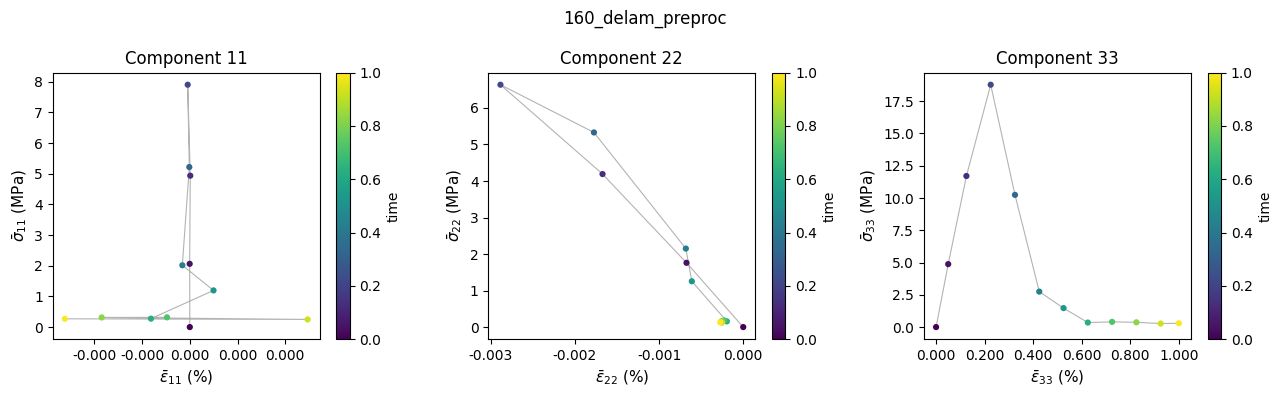

In [64]:
# ── Stress–strain curve (all diagonal components) ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

diag = ["11", "22", "33"]
for ax, lbl in zip(axes, diag):
    sc = ax.scatter(
        df[f"strain_{lbl}"] * 100,   # → %
        df[f"stress_{lbl}"],
        c=df["time"], cmap="viridis", s=20, linewidths=0,
    )
    ax.plot(
        df[f"strain_{lbl}"] * 100,
        df[f"stress_{lbl}"],
        color="0.7", lw=0.8, zorder=0,
    )
    ax.set_xlabel(f"$\\bar{{\\varepsilon}}_{{{lbl}}}$ (%)", fontsize=11)
    ax.set_ylabel(f"$\\bar{{\\sigma}}_{{{lbl}}}$ (MPa)", fontsize=11)
    ax.set_title(f"Component {lbl}")
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    fig.colorbar(sc, ax=ax, label="time")

fig.suptitle(H5_PATH.stem, fontsize=12)
fig.tight_layout()
plt.show()

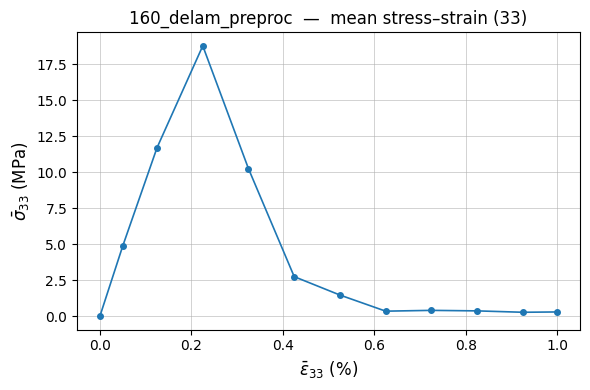

In [65]:
# ── Loading direction only (quick single-axis view) ───────────────────────────
# Change LOAD_COMP to match your loading direction ("11", "22", or "33").

LOAD_COMP = "33"

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    df[f"strain_{LOAD_COMP}"] * 100,
    df[f"stress_{LOAD_COMP}"],
    "o-", ms=4, lw=1.2,
)
ax.set_xlabel(f"$\\bar{{\\varepsilon}}_{{{LOAD_COMP}}}$ (%)", fontsize=12)
ax.set_ylabel(f"$\\bar{{\\sigma}}_{{{LOAD_COMP}}}$ (MPa)", fontsize=12)
ax.set_title(f"{H5_PATH.stem}  —  mean stress–strain ({LOAD_COMP})")
ax.grid(True, lw=0.4)
fig.tight_layout()
plt.show()

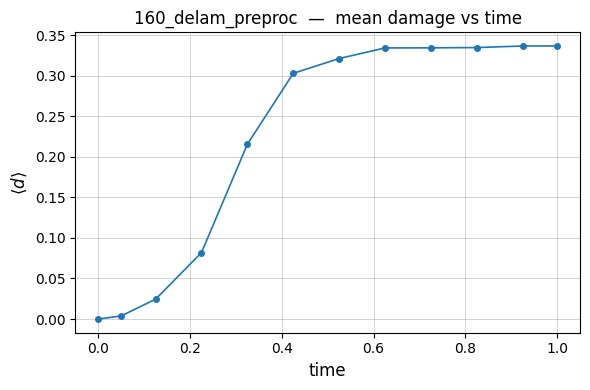

In [66]:
# ── Damage evolution (PFF runs only) ──────────────────────────────────────────

if not df["damage_mean"].isna().all():
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df["time"], df["damage_mean"], "o-", ms=4, lw=1.2)
    ax.set_xlabel("time", fontsize=12)
    ax.set_ylabel("$\\langle d \\rangle$", fontsize=12)
    ax.set_title(f"{H5_PATH.stem}  —  mean damage vs time")
    ax.grid(True, lw=0.4)
    fig.tight_layout()
    plt.show()
else:
    print("No damage field found (elastic run).")

Grid   : nx=259  ny=267  nz=29
Spacing: dx=0.020033  dy=0.020033  dz=0.019926  mm
Domain : Lx=5.1884  Ly=5.3487  Lz=0.5778  mm

W_ext  = 0.048002 MPa
EL     = 0.001478 MPa   (residual stored energy)
D      = 0.046524 MPa   (dissipated / fracture energy)
Ly     = 5.3487 mm

Gc     = 0.2488 kJ/m²


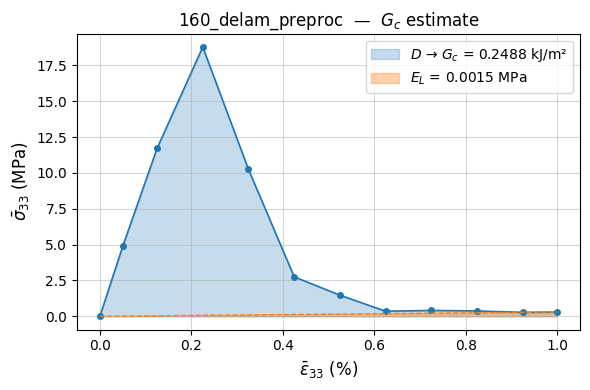

In [67]:
# ── Gc estimate via energy decomposition (Schneider & Kästner 2024, Eq. 22) ───
#
#   W_ext = EL + D
#
#   W_ext = ∫ σ̄₃₃ dε̄₃₃ × V     external work
#   EL    = ½ σ_f · ε_f × V      residual elastic energy (α keeps stiffness ≠ 0)
#   D     = W_ext − EL            dissipated ≈ crack formation energy
#
#   Gc = D / A_crack = D_vol × Ly     crack plane = XZ → A_crack = Lx·Lz → V/A = Ly
#
# 1 MPa·mm = 1 kJ/m²

# Read spacing from XDMF geometry tag (stored "dz dy dx" in ZYX order)
_tree = ET.parse(xdmf_path)
_geom = next(_tree.iter("Geometry"))
_items = [di for di in _geom.iter("DataItem")]
dz_xdmf, dy_xdmf, dx_xdmf = [float(v) for v in _items[1].text.split()]

nx, ny, nz = n
Lx = nx * dx_xdmf
Ly = ny * dy_xdmf
Lz = nz * dz_xdmf
print(f"Grid   : nx={nx}  ny={ny}  nz={nz}")
print(f"Spacing: dx={dx_xdmf:.6f}  dy={dy_xdmf:.6f}  dz={dz_xdmf:.6f}  mm")
print(f"Domain : Lx={Lx:.4f}  Ly={Ly:.4f}  Lz={Lz:.4f}  mm")
print()

eps33 = df["strain_33"].to_numpy()
sig33 = df["stress_33"].to_numpy()

W_ext_vol = np.trapezoid(sig33, eps33)      # area under loading curve  [MPa]
EL_vol    = 0.5 * sig33[-1] * eps33[-1]    # residual elastic triangle  [MPa]
D_vol     = W_ext_vol - EL_vol             # dissipated energy density  [MPa]

Gc = D_vol * Ly                            # crack plane XZ → V/A_crack = Ly  [kJ/m²]

print(f"W_ext  = {W_ext_vol:.6f} MPa")
print(f"EL     = {EL_vol:.6f} MPa   (residual stored energy)")
print(f"D      = {D_vol:.6f} MPa   (dissipated / fracture energy)")
print(f"Ly     = {Ly:.4f} mm")
print(f"\nGc     = {Gc:.4f} kJ/m²")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

ax.fill_between(eps33 * 100, sig33, alpha=0.25, color="C0",
                label=f"$D$ → $G_c$ = {Gc:.4f} kJ/m²")
ax.fill_between([0, eps33[-1] * 100], [0, sig33[-1]],
                alpha=0.35, color="C1",
                label=f"$E_L$ = {EL_vol:.4f} MPa")
ax.plot(eps33 * 100, sig33, "o-", ms=4, lw=1.2, color="C0")
ax.plot([0, eps33[-1] * 100], [0, sig33[-1]], "--", lw=1, color="C1")

ax.set_xlabel("$\\bar{\\varepsilon}_{33}$ (%)", fontsize=12)
ax.set_ylabel("$\\bar{\\sigma}_{33}$ (MPa)", fontsize=12)
ax.set_title(f"{H5_PATH.stem}  —  $G_c$ estimate")
ax.legend(fontsize=10)
ax.grid(True, lw=0.4)
fig.tight_layout()
plt.show()

In [35]:
# ── Full Voigt table ──────────────────────────────────────────────────────────

cols = ["time"] \
     + [f"strain_{l}" for l in VOIGT_LABELS] \
     + [f"stress_{l}" for l in VOIGT_LABELS] \
     + ["damage_mean"]

df[cols].round(6)

,time,strain_11,strain_22,strain_33,strain_23,strain_13,strain_12,stress_11,stress_22,stress_33,stress_23,stress_13,stress_12,damage_mean
0,0.000,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.050,0.0,-0.000010,0.00050,-0.0,0.0,-0.0,2.305179,1.944080,5.291443,-0.000000,0.000000,-0.000000,0.003196
2,0.125,0.0,-0.000027,0.00125,0.0,0.0,-0.0,5.566616,4.643111,12.810874,-0.000000,0.000000,-0.000000,0.020540
3,0.225,-0.0,-0.000048,0.00225,-0.0,0.0,-0.0,9.044773,7.412858,20.923919,0.000000,-0.000000,-0.000000,0.071933
4,0.325,-0.0,-0.000002,0.00325,-0.0,-0.0,0.0,0.295273,0.219953,0.660704,-0.000001,-0.004482,-0.004098,0.249424
5,0.425,-0.0,-0.000001,0.00425,-0.0,0.0,0.0,0.119569,0.081870,0.316128,0.000001,-0.006217,-0.005661,0.251552
6,0.525,-0.0,-0.000001,0.00525,-0.0,-0.0,0.0,0.123054,0.079576,0.333140,0.000002,-0.007739,-0.007055,0.251710
7,0.625,-0.0,-0.000002,0.00625,-0.0,0.0,0.0,0.125326,0.073758,0.350166,-0.000001,-0.009115,-0.008331,0.251852
8,0.725,0.0,-0.000002,0.00725,-0.0,-0.0,0.0,0.137001,0.077462,0.388015,-0.000000,-0.010460,-0.009565,0.251926
9,0.825,-0.0,-0.000002,0.00825,-0.0,-0.0,0.0,0.155897,0.088147,0.441534,-0.000000,-0.011902,-0.010884,0.251926


In [36]:
# ── Export CSV ────────────────────────────────────────────────────────────────

out_csv = H5_PATH.with_suffix(".mean_stress_strain.csv")
df[cols].to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")

Saved → ../output/simulation/delamination/245/245_delam_preproc.mean_stress_strain.csv
